# Tugas Implementasi: Real-time Remote Photoplethysmography (rPPG)

**Nama:** Bagas Andreanto <br>
**NIM:** 122140017 <br>
**Mata Kuliah:** Sistem Teknologi Multimedia <br>

---

##### **Import Library**

In [12]:
# Import Library
import cv2
import numpy as np
import time
import mediapipe as mp
from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import uniform_filter1d
from collections import deque
import matplotlib.pyplot as plt

# Print versions
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"MediaPipe version: {mp.__version__}")


OpenCV version: 4.12.0
NumPy version: 2.2.6
MediaPipe version: 0.10.14


##### **Konfigurasi MediaPipe**

In [13]:
# Konfigurasi parameter
FS = 30                # Target Frame Rate (FPS)
BUFFER_LEN = 300       # Panjang buffer sinyal (misal 10 detik @ 30fps)
LOW_CUT = 0.67         # 0.67 Hz (~40 BPM) sesuai ToR
HIGH_CUT = 4.0         # 4.0 Hz (~240 BPM) sesuai ToR

# Inisialisasi MediaPipe Face Detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.5)

##### **Filtring sinyal dan Estimasi BPM**

In [14]:
# Fungsi Filter Bandpass
def bandpass_filter(data, fs, lowcut, highcut, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# Fungsi Estimasi BPM
def estimate_bpm(signal_data, fs, lowcut, highcut):
    if len(signal_data) < fs * 3:
        return 0.0, np.zeros_like(signal_data)
    
    # Mengurangi rata-rata
    data = np.array(signal_data)
    detrended = data - np.mean(data)
    
    # Bandpass Filter
    filtered = bandpass_filter(detrended, fs, lowcut, highcut)
    
    # Untuk mengurangi noise frekuensi tinggi
    smoothed = uniform_filter1d(filtered, size=5)
    
    # Find Peaks
    # Jarak antar puncak minimal ~0.3 detik (agar tidak double count)
    distance = int(fs * 0.3) 
    peaks, _ = find_peaks(smoothed, distance=distance)
    
    # Hitung BPM
    if len(peaks) > 1:
        # Rata-rata jarak antar puncak dalam detik
        avg_diff_sec = np.mean(np.diff(peaks)) / fs
        bpm = 60.0 / avg_diff_sec
    else:
        bpm = 0.0
        
    return bpm, smoothed

##### **Algoritma POS untuk meningkatkan kualitas**

In [15]:
# Fungsi POS
def apply_pos_method(rgb_buffer):
    rgb_matrix = np.array(rgb_buffer)
    
    # Normalisasi temporal
    mean_color = np.mean(rgb_matrix, axis=0)
    # Hindari pembagian dengan nol
    mean_color[mean_color == 0] = 1.0 
    Cn = rgb_matrix / mean_color - 1
    
    # Cara manual agar jelas:
    r = Cn[:, 0]
    g = Cn[:, 1]
    b = Cn[:, 2]
    
    S1 = g - b
    S2 = g + b - 2*r
    
    # Alpha blending
    alpha = np.std(S1) / np.std(S2) if np.std(S2) != 0 else 1
    H = S1 + alpha * S2
    
    return H

##### **Realtime Program Loop**

In [22]:
# Buffer dan variable utama untuk pemrosesan rPPG

data_rgb = deque(maxlen=BUFFER_LEN)     # Menyimpan rata-rata RGB setiap frame
data_hijau = deque(maxlen=BUFFER_LEN)   # Fokus kanal hijau untuk rPPG dasar

rekam_hijau = []  # Arsip akhir sinyal hijau (opsional untuk plot laporan)
rekam_pos = []    # Arsip akhir sinyal POS

detak_hijau = 0.0   # BPM metode dasar
detak_pos = 0.0     # BPM metode POS

kamera = cv2.VideoCapture(0)
waktu_update = time.time()


# Proses utama video 

try:
    while kamera.isOpened():
        
        berhasil, frame_asli = kamera.read()
        if not berhasil:
            break

        # --- Konversi frame BGR → RGB (MediaPipe wajib RGB)
        frame_rgb = cv2.cvtColor(frame_asli, cv2.COLOR_BGR2RGB)

        # --- Deteksi wajah dengan MediaPipe
        hasil = face_detection.process(frame_rgb)

        roi_ok = False  # flag untuk memastikan ROI layak dipakai

        if hasil.detections:
            for det in hasil.detections:
                
                bbox = det.location_data.relative_bounding_box
                tinggi, lebar, _ = frame_asli.shape

                # Konversi bounding box relatif → piksel
                px = int(bbox.xmin * lebar)
                py = int(bbox.ymin * tinggi)
                pw = int(bbox.width * lebar)
                ph = int(bbox.height * tinggi)

                # Ambil ROI sesuai bounding box wajah
                rx, ry, rw, rh = px, py, pw, ph

                # Validasi posisi agar tidak keluar frame
                if rx >= 0 and ry >= 0 and (rx + rw) <= lebar and (ry + rh) <= tinggi:
                    
                    roi = frame_rgb[ry:ry+rh, rx:rx+rw]

                    if roi.size > 0:
                        # Hitung rata-rata warna dalam ROI
                        mean_val = np.mean(roi, axis=(0, 1))  # [R, G, B]

                        # Simpan ke buffer
                        data_rgb.append(mean_val)
                        data_hijau.append(mean_val[1])  # kanal hijau

                        roi_ok = True

                        # Gambar kotak deteksi wajah
                        cv2.rectangle(frame_asli, (rx, ry), (rx+rw, ry+rh), (0, 255, 0), 2)
                        cv2.putText(frame_asli, "Deteksi Wajah", (rx, ry-5),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)


        # Perhitungan BPM (setiap 1 detik)
        if roi_ok and len(data_hijau) > FS * 2:  # minimal 2 detik data tersimpan
            sekarang = time.time()

            if sekarang - waktu_update >= 1:

                # ---- Metode Dasar Kanal Hijau ----
                detak_hijau, _ = estimate_bpm(list(data_hijau),
                                              FS, LOW_CUT, HIGH_CUT)

                # ---- Metode POS ----
                sinyal_pos = apply_pos_method(list(data_rgb))
                detak_pos, _ = estimate_bpm(sinyal_pos,
                                            FS, LOW_CUT, HIGH_CUT)

                waktu_update = sekarang

                # Simpan untuk laporan (opsional)
                rekam_hijau.append(detak_hijau)
                rekam_pos.append(detak_pos)


        # Tampilkan di Layar
        cv2.putText(frame_asli, f"Detak Jantung Hijau : {detak_hijau:.1f} BPM",
                    (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 100), 2)

        cv2.putText(frame_asli, f"Detak Jantung POS   : {detak_pos:.1f} BPM",
                    (20, 85), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255, 255, 150), 2)

        cv2.imshow("Pemantauan rPPG Real-time", frame_asli)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break


finally:
    kamera.release()
    cv2.destroyAllWindows()
    print("Proses pengambilan data selesai. Menyusun hasil laporan...")


Proses pengambilan data selesai. Menyusun hasil laporan...


##### **Visualisasi Plot Sinyal**

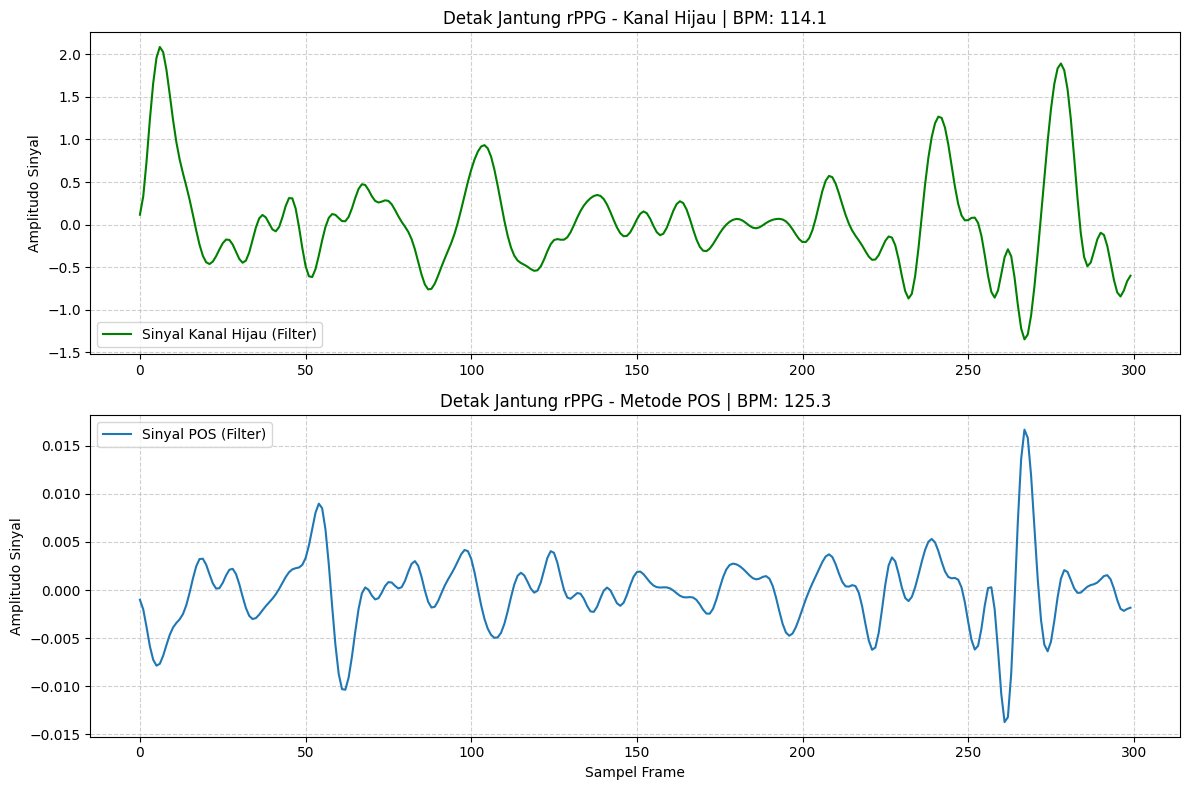

In [25]:
# Plot Signa Terakhir Untuk Laporan 

# Mengecek apakah sinyal yang direkam cukup panjang
if len(data_rgb) > FS * 2:
    
    # Ambil data terakhir (snapshot buffer)
    sinyal_hijau = list(data_hijau)
    sinyal_pos_raw = apply_pos_method(list(data_rgb))
    
    # Hitung BPM + ambil sinyal hasil filter
    bpm_hijau_plot, hijau_filter = estimate_bpm(sinyal_hijau, FS, LOW_CUT, HIGH_CUT)
    bpm_pos_plot, pos_filter = estimate_bpm(sinyal_pos_raw, FS, LOW_CUT, HIGH_CUT)

    # Mulai plotting
    plt.figure(figsize=(12, 8))

    # 1. Grafik Kanal Hijau — RPPG Dasar
    plt.subplot(2, 1, 1)
    plt.plot(hijau_filter, label="Sinyal Kanal Hijau (Filter)", color="green")
    plt.title(f"Detak Jantung rPPG - Kanal Hijau | BPM: {bpm_hijau_plot:.1f}")
    plt.ylabel("Amplitudo Sinyal")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # 2. Grafik POS Method — Perbaikan Sinyal
    plt.subplot(2, 1, 2)
    plt.plot(pos_filter, label="Sinyal POS (Filter)")
    plt.title(f"Detak Jantung rPPG - Metode POS | BPM: {bpm_pos_plot:.1f}")
    plt.xlabel("Sampel Frame")
    plt.ylabel("Amplitudo Sinyal")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

else:
    print("❗ Data belum cukup untuk ditampilkan. Silakan jalankan kamera lebih lama.")


#### **Penjelasan** 

##### Deteksi dan Ekstraksi Sinyal
Sistem melakukan deteksi wajah menggunakan MediaPipe Face Detection dan Face Mesh. Area dahi dipilih sebagai Region of Interest (ROI) karena memiliki respon fotopletismografi yang paling stabil. Dari ROI tersebut, nilai rata-rata intensitas kanal hijau diekstraksi sebagai sinyal dasar detak jantung.



##### Tahapan Pemrosesan Sinyal
Beberapa tahap pemrosesan dilakukan untuk memperoleh sinyal detak jantung yang bersih:

1. **Detrending**
   Menghilangkan komponen DC agar sinyal fluktuasi detak jantung dapat terlihat dengan jelas.

2. **Bandpass Filter Butterworth**
   Filter orde 3 dengan rentang frekuensi 0.67–4.0 Hz digunakan untuk membatasi sinyal sesuai rentang detak jantung manusia, serta mereduksi noise frekuensi rendah dan tinggi.

3. **Estimasi BPM**
   Estimasi detak jantung dilakukan melalui perhitungan puncak sinyal (peak detection) pada domain waktu.


##### Peningkatan Akurasi: Metode POS
Selain metode kanal hijau dasar, sistem juga menggunakan metode POS (Plane-Orthogonal-to-Skin). Metode ini memproyeksikan komponen warna RGB ke bidang ortogonal sehingga perubahan cahaya dan pergerakan kepala tidak langsung mempengaruhi sinyal utama. Dengan demikian, sinyal yang dihasilkan lebih stabil dibandingkan penggunaan kanal hijau saja.



##### Implementasi Real-time
Proses pengukuran dilakukan secara real-time dengan pendekatan sliding window sepanjang 300 frame (±10 detik pada 30 FPS). Estimasi nilai BPM diperbarui setiap 1 detik agar pembacaan tetap responsif, sementara buffer data diperbarui secara bergulir untuk menjaga performa sistem.



Pada implementasi ini, proses detrending diterapkan pada sinyal kanal hijau dan juga pada sinyal hasil transformasi metode POS. Pendekatan ini digunakan untuk membandingkan kestabilan sinyal dan menentukan metode paling sesuai dalam kondisi pencahayaan serta pergerakan yang berbeda.
